# Delete-ramp command test trend plots

This notebook reads `删除ramp命令测试.MD`, parses the UART log lines, and plots the main control variables.

In [1]:
from pathlib import Path
import re

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False

## Load and parse the log

In [2]:
data_path = Path("删除ramp命令测试.MD")

# Fallback: allow running the notebook from the repository root.
if not data_path.exists():
    data_path = Path("KELI_MOTOR/report/测试数据/new/删除ramp命令测试.MD")

log_text = data_path.read_text(encoding="utf-8")
print(data_path.resolve())

/Users/snow/polito/01 electronics/Project/KELI_MOTOR/report/测试数据/new/删除ramp命令测试.MD


In [3]:
pattern = re.compile(
    r"\[(?P<state>[^\]]+)\]\s+"
    r"set=(?P<set>[-+]?\d+(?:\.\d+)?)\s+"
    r"(?:setR=(?P<setR>[-+]?\d+(?:\.\d+)?)\s+)?"
    r"RPM=(?P<rpm>[-+]?\d+(?:\.\d+)?)\s+"
    r"duty=\s*(?P<duty>\d+)\s+"
    r"\((?P<duty_percent>[-+]?\d+(?:\.\d+)?)%\)\s+"
    r"adc=\s*(?P<adc>\d+)\s+"
    r"(?:curr_raw|raw)=\s*(?P<curr_raw>\d+)\s+"
    r"iset=(?P<iset>[-+]?\d+(?:\.\d+)?)mA\s+"
    r"curr=(?P<curr>[-+]?\d+(?:\.\d+)?)mA"
)

rows = []
for line_no, line in enumerate(log_text.splitlines(), start=1):
    match = pattern.search(line)
    if not match:
        continue
    row = match.groupdict()
    row["line_no"] = line_no
    row["state"] = row["state"].strip()
    for key in ["set", "setR", "rpm", "duty_percent", "iset", "curr"]:
        if row.get(key) is not None:
            row[key] = float(row[key])
    for key in ["duty", "adc", "curr_raw"]:
        row[key] = int(row[key])
    rows.append(row)

df = pd.DataFrame(rows)

# The log was captured at about 5 Hz. Change this value if a different print period was used.
sample_period_s = 0.2
df["sample"] = range(len(df))
df["time_s"] = df["sample"] * sample_period_s

print(f"Parsed {len(df)} rows")
df.head()

Parsed 148 rows


,state,set,setR,rpm,duty,duty_percent,adc,curr_raw,iset,curr,line_no,sample,time_s
0,IDLE,0.0,0.0,0.0,0,0.0,10,2046,0.0,0.0,1,0,0.0
1,IDLE,0.0,0.0,0.0,0,0.0,10,2046,0.0,0.0,2,1,0.2
2,IDLE,0.0,0.0,0.0,0,0.0,10,2045,0.0,0.0,3,2,0.4
3,IDLE,0.0,0.0,0.0,0,0.0,10,2046,0.0,0.0,4,3,0.6
4,IDLE,0.0,0.0,0.0,0,0.0,9,2046,0.0,0.0,5,4,0.8


## Summary

In [4]:
display(df.describe())
display(df["state"].value_counts())

,set,setR,rpm,duty,duty_percent,adc,curr_raw,iset,curr,line_no,sample,time_s
count,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
mean,58.353378,58.257432,56.422973,1473.195946,35.972973,2308.425676,2307.270270,101.808108,41.289865,74.500000,73.500000,14.700000
std,35.466354,35.609891,34.670847,862.569754,21.066189,1484.527626,173.780908,86.718649,19.753339,42.868014,42.868014,8.573603
min,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2035.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,36.100000,36.100000,44.100000,1196.750000,29.200000,1279.000000,2228.750000,43.175000,36.025000,37.750000,36.750000,7.350000
50%,50.600000,50.600000,51.100000,1363.000000,33.300000,1917.000000,2280.500000,45.650000,47.250000,74.500000,73.500000,14.700000
75%,100.000000,100.000000,90.825000,2317.500000,56.575000,4094.000000,2401.000000,199.425000,55.150000,111.250000,110.250000,22.050000
max,100.000000,100.000000,99.300000,2523.000000,61.600000,4095.000000,2876.000000,238.900000,73.900000,148.000000,147.000000,29.400000


state
RUN      117
IDLE      20
START     10
STOP       1
Name: count, dtype: int64

## Speed trend

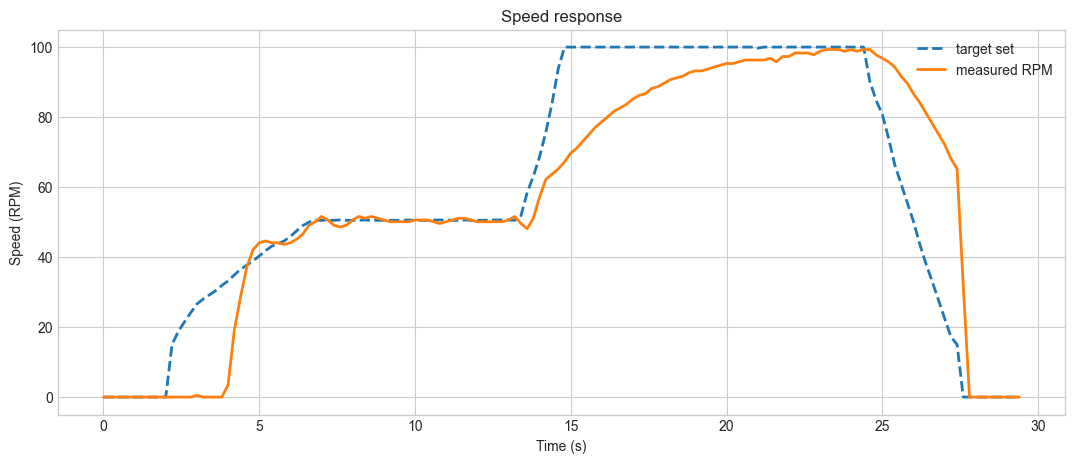

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["time_s"], df["set"], label="target set", linewidth=2, linestyle="--")
ax.plot(df["time_s"], df["rpm"], label="measured RPM", linewidth=2, linestyle="-")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (RPM)")
ax.set_title("Speed response")
ax.legend()
plt.show()

## Duty and current trend

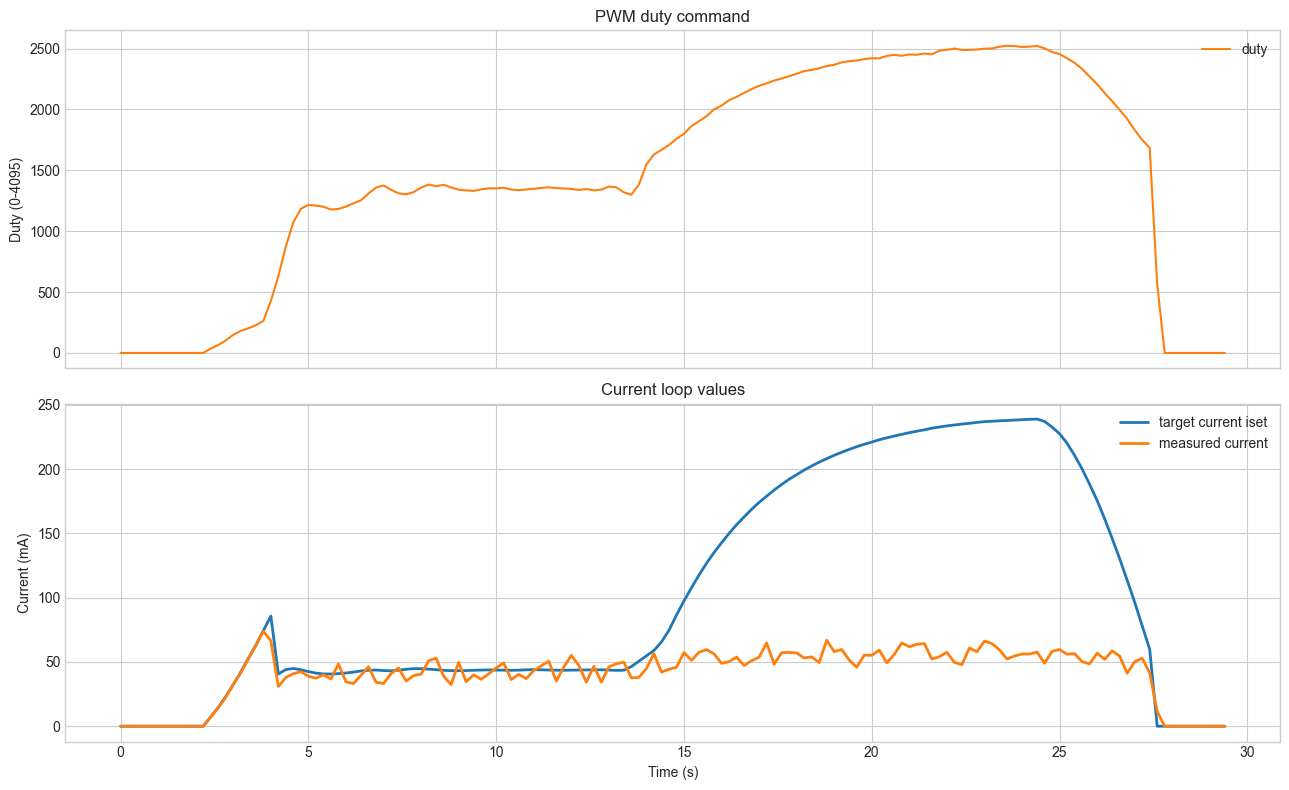

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(df["time_s"], df["duty"], label="duty", color="tab:orange")
axes[0].set_ylabel("Duty (0-4095)")
axes[0].set_title("PWM duty command")
axes[0].legend()

axes[1].plot(df["time_s"], df["iset"], label="target current iset", linewidth=2)
axes[1].plot(df["time_s"], df["curr"], label="measured current", linewidth=2)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Current (mA)")
axes[1].set_title("Current loop values")
axes[1].legend()

plt.tight_layout()
plt.show()

## State and ADC trend

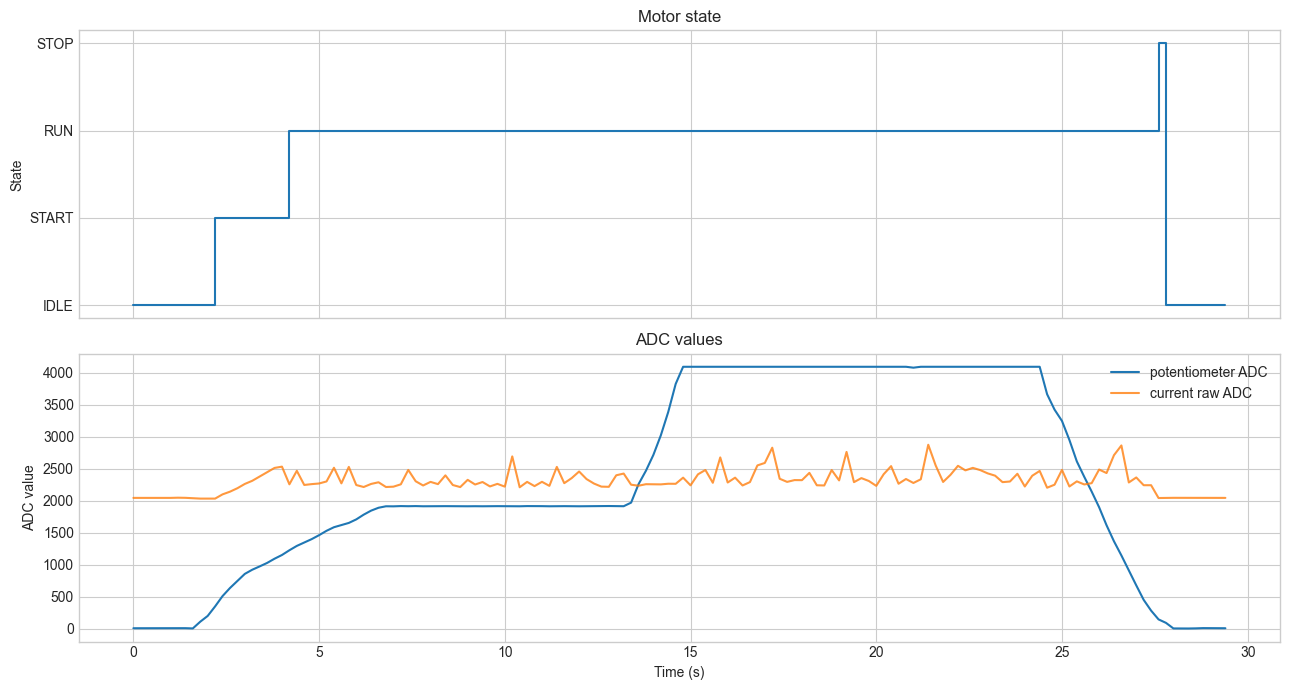

In [7]:
state_codes = {name: idx for idx, name in enumerate(df["state"].drop_duplicates())}
df["state_code"] = df["state"].map(state_codes)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].step(df["time_s"], df["state_code"], where="post")
axes[0].set_yticks(list(state_codes.values()))
axes[0].set_yticklabels(list(state_codes.keys()))
axes[0].set_ylabel("State")
axes[0].set_title("Motor state")

axes[1].plot(df["time_s"], df["adc"], label="potentiometer ADC")
axes[1].plot(df["time_s"], df["curr_raw"], label="current raw ADC", alpha=0.8)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("ADC value")
axes[1].set_title("ADC values")
axes[1].legend()

plt.tight_layout()
plt.show()

## Combined overview

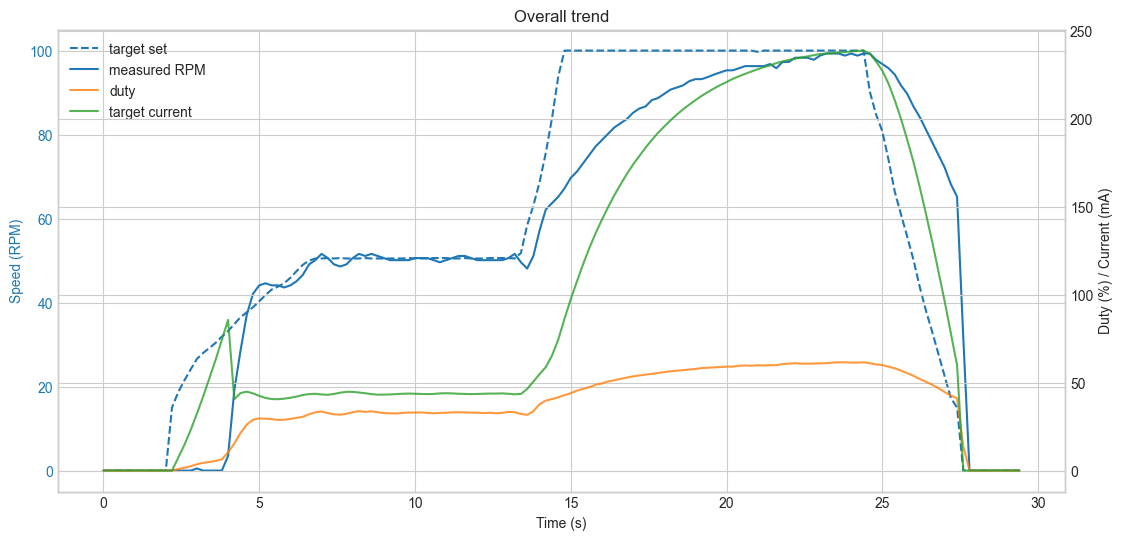

In [8]:
fig, ax1 = plt.subplots(figsize=(13, 6))

ax1.plot(df["time_s"], df["set"], label="target set", color="tab:blue", linestyle="--")
ax1.plot(df["time_s"], df["rpm"], label="measured RPM", color="tab:blue")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Speed (RPM)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df["time_s"], df["duty_percent"], label="duty", color="tab:orange", alpha=0.8)
ax2.plot(df["time_s"], df["iset"], label="target current", color="tab:green", alpha=0.8)
ax2.set_ylabel("Duty (%) / Current (mA)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Overall trend")
plt.show()